In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_all = pd.read_csv("result_combined.csv")


In [44]:
df_all_hard = df_all.copy()
df_all = df_all[df_all["steps_baseline"] != 201].copy()

diff =  df_all["steps_with_help_paper2"] - df_all["steps_with_help_gr"]


In [51]:
from scipy.stats import wilcoxon
rng = np.random.default_rng(0)

diff = df_all["steps_with_help_paper2"] - df_all["steps_with_help_gr"]

boot_means = [
    rng.choice(diff, size=len(diff), replace=True).mean()
    for _ in range(10000)
]

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print("95% CI:", ci_low, ci_high)

95% CI: 0.9289447731755425 2.4792899408284024


In [50]:
alpha = 0.05

if diff.mean() > 0 and p_value_one_sided < alpha:
    print("steps_with_help_gr is significantly larger than steps_with_help_paper2")
else:
    print("No significant evidence that gr > paper2")

steps_with_help_gr is significantly larger than steps_with_help_paper2


In [3]:
# 读取数据
# 需要对比的“帮助策略”列名与展示名
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",  "Goal Recognition"),
    ("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper", "paper"),
    ("steps_with_help_paper2", "paper2")
]

# 基线列名
base_col = "steps_baseline"

# 也顺手打印 baseline 的均值
avg_steps = float(np.nanmean(df_all[base_col].astype(float)))
print(f"Baseline avg steps: {avg_steps:.2f}")

# 逐个帮助策略与 baseline 对比
for col, label in help_cols:
    print("-" * 60)
    if col not in df_all.columns:
        print(f"[INFO] {dataset}: '{col}' not found; skip this help variant.")
        continue

    # 向量化清洗
    s  = pd.to_numeric(df_all[base_col], errors="coerce")
    sh = pd.to_numeric(df_all[col],       errors="coerce")

    # 过滤缺失
    mask = s.notna() & sh.notna()
    s, sh = s[mask].astype(float), sh[mask].astype(float)

    # 计算差值/比例/成功率
    diff = s - sh
    succ_rate = float((diff > 0).mean()) if len(diff) else 0.0

    # 仅在 s>0 时计算相对比例
    mask_pos = s > 0
    mean_ratio = float(((diff[mask_pos]) / s[mask_pos]).mean()) if mask_pos.any() else 0.0

    mean_diff = float(diff.mean()) if len(diff) else 0.0
    avg_steps_help = float(sh.mean()) if len(sh) else float("nan")

    # 输出结果（英文）
    print(
        f"[{label}]  Δsteps(mean)={mean_diff:.2f},  "
        f"Mean ratio={mean_ratio:.2%},  "
        f"Success(reduced)={succ_rate:.2%},  "
        f"Avg steps (help)={avg_steps_help:.2f}"
    )

Baseline avg steps: 54.55
------------------------------------------------------------
[Greedy]  Δsteps(mean)=4.13,  Mean ratio=4.16%,  Success(reduced)=40.04%,  Avg steps (help)=50.42
------------------------------------------------------------
[Uniform]  Δsteps(mean)=10.14,  Mean ratio=13.12%,  Success(reduced)=45.17%,  Avg steps (help)=44.41
------------------------------------------------------------
[Goal Recognition]  Δsteps(mean)=13.71,  Mean ratio=18.50%,  Success(reduced)=64.69%,  Avg steps (help)=40.84
------------------------------------------------------------
[Upperbound]  Δsteps(mean)=15.87,  Mean ratio=22.40%,  Success(reduced)=79.49%,  Avg steps (help)=38.68
------------------------------------------------------------
[paper]  Δsteps(mean)=9.93,  Mean ratio=13.00%,  Success(reduced)=58.38%,  Avg steps (help)=44.62
------------------------------------------------------------
[paper2]  Δsteps(mean)=12.03,  Mean ratio=16.27%,  Success(reduced)=62.33%,  Avg steps (help)=42.

In [4]:
import numpy as np
import pandas as pd

# 假设 df_all 已加载完毕，并包含 "num_rows" 与 "num_cols" 列

# 生成一个新的分组列，例如 "3x3"
df_all["map_size"] = df_all.apply(lambda x: f"{int(x['num_rows'])}x{int(x['num_cols'])}", axis=1)

# 要对比的帮助策略列名与展示名
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",      "Goal Recognition"),
    ("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper",   "Counter-Planning (Step)"),
    ("steps_with_help_paper2",  "Counter-Planning (Threshold)")
]

base_col = "steps_baseline"

# 打印整体 baseline 均值
avg_steps_all = float(np.nanmean(df_all[base_col].astype(float)))
print(f"Baseline avg steps (overall): {avg_steps_all:.2f}")
print("=" * 80)

# 对每个 map_size 分组
for size, df_group in df_all.groupby("map_size"):
    print(f"\n==========  map size = {size}  ==========")
    avg_steps = float(np.nanmean(df_group[base_col].astype(float)))
    print(f"Baseline avg steps: {avg_steps:.2f}")

    # 逐个策略对比 baseline
    for col, label in help_cols:
        print("-" * 60)
        if col not in df_group.columns:
            print(f"[INFO] '{col}' not found; skip this variant.")
            continue

        s  = pd.to_numeric(df_group[base_col], errors="coerce")
        sh = pd.to_numeric(df_group[col], errors="coerce")

        mask = s.notna() & sh.notna()
        s, sh = s[mask].astype(float), sh[mask].astype(float)

        diff = s - sh
        succ_rate = float((diff > 0).mean()) if len(diff) else 0.0

        mask_pos = s > 0
        mean_ratio = float(((diff[mask_pos]) / s[mask_pos]).mean()) if mask_pos.any() else 0.0
        mean_diff = float(diff.mean()) if len(diff) else 0.0
        avg_steps_help = float(sh.mean()) if len(sh) else float("nan")

        # 输出结果（英文）
        print(
            f"[{label}]  Δsteps(mean)={mean_diff:.2f},  "
            f"Mean ratio={mean_ratio*100:.2f}%,  "
            f"Success(reduced)={succ_rate*100:.2f}%,  "
            f"Avg steps (help)={avg_steps_help:.2f}"
        )


Baseline avg steps (overall): 54.55

==========  map size = 3x3  ==========
Baseline avg steps: 41.76
------------------------------------------------------------
[Greedy]  Δsteps(mean)=4.84,  Mean ratio=9.12%,  Success(reduced)=47.18%,  Avg steps (help)=36.92
------------------------------------------------------------
[Uniform]  Δsteps(mean)=7.38,  Mean ratio=15.29%,  Success(reduced)=53.52%,  Avg steps (help)=34.38
------------------------------------------------------------
[Goal Recognition]  Δsteps(mean)=9.67,  Mean ratio=20.26%,  Success(reduced)=76.06%,  Avg steps (help)=32.09
------------------------------------------------------------
[Upperbound]  Δsteps(mean)=12.36,  Mean ratio=26.25%,  Success(reduced)=89.44%,  Avg steps (help)=29.40
------------------------------------------------------------
[Counter-Planning (Step)]  Δsteps(mean)=6.46,  Mean ratio=13.38%,  Success(reduced)=67.61%,  Avg steps (help)=35.30
------------------------------------------------------------
[Coun

In [5]:
import numpy as np
import pandas as pd
import ast

# 计算每行 goal 的数量
df_all["goals"] = df_all["goals"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_all["num_goals"] = df_all["goals"].apply(len)

# 假设 df_all 已加载完毕，并包含 "num_goal" 列

# 要对比的帮助策略列名与展示名
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",      "Goal Recognition"),
    ("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper",   "Counter-Planning (Step)"),
    ("steps_with_help_paper2",  "Counter-Planning (Threshold)")
]

base_col = "steps_baseline"

# 打印整体 baseline 均值
avg_steps_all = float(np.nanmean(df_all[base_col].astype(float)))
print(f"Baseline avg steps (overall): {avg_steps_all:.2f}")
print("=" * 80)

# 对每个 num_goal 分组
for num, df_group in df_all.groupby("num_goals"):
    print(f"\n==========  num_goal = {num}  ==========")
    avg_steps = float(np.nanmean(df_group[base_col].astype(float)))
    print(f"Baseline avg steps: {avg_steps:.2f}")

    # 逐个策略对比 baseline
    for col, label in help_cols:
        print("-" * 60)
        if col not in df_group.columns:
            print(f"[INFO] '{col}' not found; skip this variant.")
            continue

        s  = pd.to_numeric(df_group[base_col], errors="coerce")
        sh = pd.to_numeric(df_group[col], errors="coerce")

        mask = s.notna() & sh.notna()
        s, sh = s[mask].astype(float), sh[mask].astype(float)

        diff = s - sh
        succ_rate = float((diff > 0).mean()) if len(diff) else 0.0

        mask_pos = s > 0
        mean_ratio = float(((diff[mask_pos]) / s[mask_pos]).mean()) if mask_pos.any() else 0.0
        mean_diff = float(diff.mean()) if len(diff) else 0.0
        avg_steps_help = float(sh.mean()) if len(sh) else float("nan")

        # 输出结果（英文）
        print(
            f"[{label}]  Δsteps(mean)={mean_diff:.2f},  "
            f"Mean ratio={mean_ratio*100:.2f}%,  "
            f"Success(reduced)={succ_rate*100:.2f}%,  "
            f"Avg steps (help)={avg_steps_help:.2f}"
        )


Baseline avg steps (overall): 54.55

==========  num_goal = 2  ==========
Baseline avg steps: 54.48
------------------------------------------------------------
[Greedy]  Δsteps(mean)=1.86,  Mean ratio=1.69%,  Success(reduced)=34.00%,  Avg steps (help)=52.62
------------------------------------------------------------
[Uniform]  Δsteps(mean)=13.29,  Mean ratio=18.52%,  Success(reduced)=61.00%,  Avg steps (help)=41.19
------------------------------------------------------------
[Goal Recognition]  Δsteps(mean)=14.42,  Mean ratio=20.19%,  Success(reduced)=70.00%,  Avg steps (help)=40.06
------------------------------------------------------------
[Upperbound]  Δsteps(mean)=15.11,  Mean ratio=21.64%,  Success(reduced)=78.00%,  Avg steps (help)=39.37
------------------------------------------------------------
[Counter-Planning (Step)]  Δsteps(mean)=11.44,  Mean ratio=14.91%,  Success(reduced)=67.00%,  Avg steps (help)=43.04
------------------------------------------------------------
[Cou

In [6]:
df_all_hard = df_all_hard[df_all_hard["steps_baseline"] == 201].copy()


# 读取数据
# 需要对比的“帮助策略”列名与展示名
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",  "Goal Recognition"),
    ("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper", "paper"),
    ("steps_with_help_paper2", "paper2")
]

# 基线列名
base_col = "steps_baseline"

# 也顺手打印 baseline 的均值
avg_steps = float(np.nanmean(df_all_hard[base_col].astype(float)))
print(f"Baseline avg steps: {avg_steps:.2f}")

# 逐个帮助策略与 baseline 对比
for col, label in help_cols:
    print("-" * 60)
    if col not in df_all_hard.columns:
        print(f"[INFO] {dataset}: '{col}' not found; skip this help variant.")
        continue

    # 向量化清洗
    s  = pd.to_numeric(df_all_hard[base_col], errors="coerce")
    sh = pd.to_numeric(df_all_hard[col],       errors="coerce")

    # 过滤缺失
    mask = s.notna() & sh.notna()
    s, sh = s[mask].astype(float), sh[mask].astype(float)

    # 计算差值/比例/成功率
    diff = s - sh
    succ_rate = float((diff > 0).mean()) if len(diff) else 0.0

    # 仅在 s>0 时计算相对比例
    mask_pos = s > 0
    mean_ratio = float(((diff[mask_pos]) / s[mask_pos]).mean()) if mask_pos.any() else 0.0

    mean_diff = float(diff.mean()) if len(diff) else 0.0
    avg_steps_help = float(sh.mean()) if len(sh) else float("nan")

    # 输出结果（英文）
    print(
        f"[{label}]  Δsteps(mean)={mean_diff:.2f},  "
        f"Mean ratio={mean_ratio:.2%},  "
        f"Success(reduced)={succ_rate:.2%},  "
        f"Avg steps (help)={avg_steps_help:.2f}"
    )

Baseline avg steps: 201.00
------------------------------------------------------------
[Greedy]  Δsteps(mean)=117.39,  Mean ratio=58.40%,  Success(reduced)=100.00%,  Avg steps (help)=83.61
------------------------------------------------------------
[Uniform]  Δsteps(mean)=144.33,  Mean ratio=71.80%,  Success(reduced)=100.00%,  Avg steps (help)=56.67
------------------------------------------------------------
[Goal Recognition]  Δsteps(mean)=146.65,  Mean ratio=72.96%,  Success(reduced)=100.00%,  Avg steps (help)=54.35
------------------------------------------------------------
[Upperbound]  Δsteps(mean)=154.33,  Mean ratio=76.78%,  Success(reduced)=100.00%,  Avg steps (help)=46.67
------------------------------------------------------------
[paper]  Δsteps(mean)=133.74,  Mean ratio=66.54%,  Success(reduced)=100.00%,  Avg steps (help)=67.26
------------------------------------------------------------
[paper2]  Δsteps(mean)=135.41,  Mean ratio=67.37%,  Success(reduced)=100.00%,  Avg 

In [7]:
# 去掉缺失值（保证两列都能比较）
df = df_all_hard.dropna(subset=["steps_with_help_uniform", "steps_with_help_gr","steps_with_help_paper","steps_with_help_paper2"])
import ast
# 确保 goals 列转为列表对象
df["goals"] = df["goals"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# 计算每行 goal 的数量
df["num_goals"] = df["goals"].apply(len)
# 按数量统计出现次数
goal_counts = df["num_goals"].value_counts().sort_index()
print("=== Goal count distribution ===")
print(goal_counts)

=== Goal count distribution ===
num_goals
2    12
3     7
4     7
5    10
6    10
Name: count, dtype: int64


In [8]:
# 去掉缺失值（保证两列都能比较）
df = df_all.dropna(subset=["steps_with_help_uniform", "steps_with_help_gr","steps_with_help_paper","steps_with_help_paper2"])
import ast
# 确保 goals 列转为列表对象
df["goals"] = df["goals"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# 计算每行 goal 的数量
df["num_goals"] = df["goals"].apply(len)
# 按数量统计出现次数
goal_counts = df["num_goals"].value_counts().sort_index()
print("=== Goal count distribution ===")
print(goal_counts)

=== Goal count distribution ===
num_goals
2    100
3    108
4     98
5    104
6     97
Name: count, dtype: int64


In [9]:
# 计算差值
df["diff_uniform_gr"] = df["steps_with_help_uniform"] - df["steps_with_help_gr"]
df["abs_diff"] = df["diff_uniform_gr"].abs()


# uniform 更大（baseline 步数更多 → 更差）
uniform_better = df[df["diff_uniform_gr"] < 0].copy()  # uniform 更优（步数少）
gr_better = df[df["diff_uniform_gr"] > 0].copy()       # gr 更优（步数少）

print(f"Uniform higher count: {len(uniform_better)}")
print(f"GR higher count: {len(gr_better)}")

# 分组平均差距（哪一类差得更多）
mean_diff_uniform_better = uniform_better["abs_diff"].mean()
mean_diff_gr_better = gr_better["abs_diff"].mean()

print("\n=== Group-wise average differences ===")
print(f"Average difference (Uniform better cases): {mean_diff_uniform_better:.2f}")
print(f"Average difference (GR better cases): {mean_diff_gr_better:.2f}")

Uniform higher count: 32
GR higher count: 173

=== Group-wise average differences ===
Average difference (Uniform better cases): 5.03
Average difference (GR better cases): 11.39


           Uniform better  GR better
num_goals                           
2                       7         22
3                       5         36
4                       8         36
5                       6         45
6                       6         34


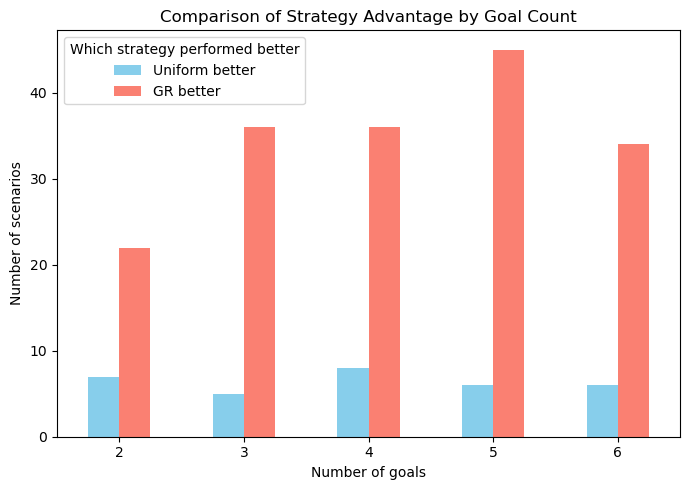

In [10]:
uniform_counts = uniform_better["num_goals"].value_counts().sort_index()
gr_counts = gr_better["num_goals"].value_counts().sort_index()

# 组合成一个 DataFrame 便于对比
compare_df = pd.DataFrame({
    "Uniform better": uniform_counts,
    "GR better": gr_counts
}).fillna(0).astype(int)

print(compare_df)

# === 双柱对比图 ===
compare_df.plot(kind="bar", figsize=(7, 5), color=["skyblue", "salmon"])
plt.title("Comparison of Strategy Advantage by Goal Count")
plt.xlabel("Number of goals")
plt.ylabel("Number of scenarios")
plt.xticks(rotation=0)
plt.legend(title="Which strategy performed better")
plt.tight_layout()
plt.show()

In [11]:
# 计算差值
df["diff_uniform_gr"] = df["steps_with_help_paper"] - df["steps_with_help_gr"]
df["abs_diff"] = df["diff_uniform_gr"].abs()


# uniform 更大（baseline 步数更多 → 更差）
uniform_better = df[df["diff_uniform_gr"] < 0].copy()  # uniform 更优（步数少）
gr_better = df[df["diff_uniform_gr"] > 0].copy()       # gr 更优（步数少）

print(f"Uniform higher count: {len(uniform_better)}")
print(f"GR higher count: {len(gr_better)}")

# 分组平均差距（哪一类差得更多）
mean_diff_uniform_better = uniform_better["abs_diff"].mean()
mean_diff_gr_better = gr_better["abs_diff"].mean()

print("\n=== Group-wise average differences ===")
print(f"Average difference (Paper better cases): {mean_diff_uniform_better:.2f}")
print(f"Average difference (GR better cases): {mean_diff_gr_better:.2f}")

Uniform higher count: 117
GR higher count: 181

=== Group-wise average differences ===
Average difference (Paper better cases): 8.21
Average difference (GR better cases): 15.88


           Paper better  GR better
num_goals                         
2                    21         30
3                    19         33
4                    24         37
5                    29         51
6                    24         30


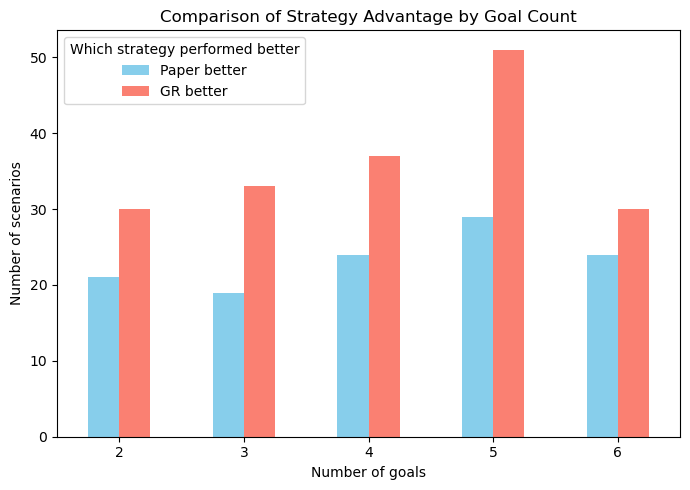

In [12]:
uniform_counts = uniform_better["num_goals"].value_counts().sort_index()
gr_counts = gr_better["num_goals"].value_counts().sort_index()

# 组合成一个 DataFrame 便于对比
compare_df = pd.DataFrame({
    "Paper better": uniform_counts,
    "GR better": gr_counts
}).fillna(0).astype(int)

print(compare_df)

# === 双柱对比图 ===
compare_df.plot(kind="bar", figsize=(7, 5), color=["skyblue", "salmon"])
plt.title("Comparison of Strategy Advantage by Goal Count")
plt.xlabel("Number of goals")
plt.ylabel("Number of scenarios")
plt.xticks(rotation=0)
plt.legend(title="Which strategy performed better")
plt.tight_layout()
plt.show()

In [13]:
# 计算差值
df["diff_uniform_gr"] = df["steps_with_help_paper2"] - df["steps_with_help_gr"]
df["abs_diff"] = df["diff_uniform_gr"].abs()


# uniform 更大（baseline 步数更多 → 更差）
uniform_better = df[df["diff_uniform_gr"] < 0].copy()  # uniform 更优（步数少）
gr_better = df[df["diff_uniform_gr"] > 0].copy()       # gr 更优（步数少）

print(f"Uniform higher count: {len(uniform_better)}")
print(f"GR higher count: {len(gr_better)}")

# 分组平均差距（哪一类差得更多）
mean_diff_uniform_better = uniform_better["abs_diff"].mean()
mean_diff_gr_better = gr_better["abs_diff"].mean()

print("\n=== Group-wise average differences ===")
print(f"Average difference (Paper2 better cases): {mean_diff_uniform_better:.2f}")
print(f"Average difference (GR better cases): {mean_diff_gr_better:.2f}")

Uniform higher count: 103
GR higher count: 130

=== Group-wise average differences ===
Average difference (Paper2 better cases): 6.44
Average difference (GR better cases): 11.65


   num_goals   gr_delta   p2_delta
0          2  14.420000  14.530000
1          3   9.888889   8.731481
2          4  17.010204  13.836735
3          5  15.884615  12.750000
4          6  11.567010  10.525773


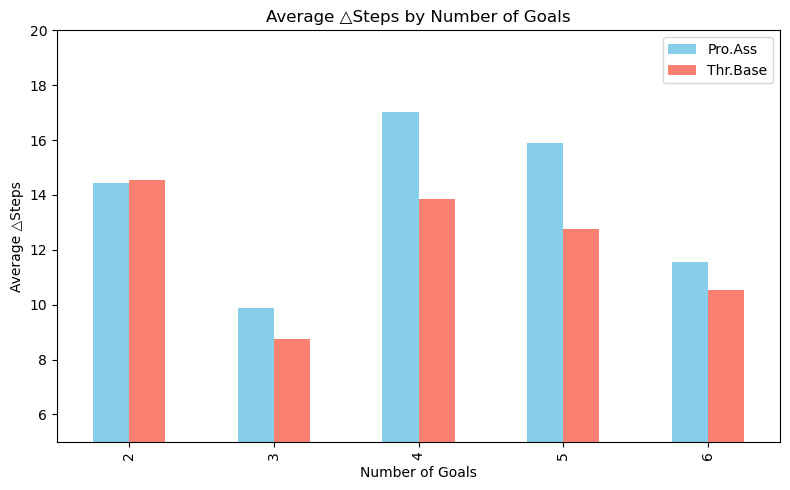

In [14]:
df["gr_delta"] = df["steps_baseline"] - df["steps_with_help_gr"]

df["p2_delta"] = df["steps_baseline"] - df["steps_with_help_paper2"]

avg_by_num = (
    df.groupby("num_goals")[["gr_delta",
                            "p2_delta"]]
      .mean()
      .reset_index()
)

print(avg_by_num)

ax = avg_by_num.plot(
    x="num_goals",
    y=["gr_delta", "p2_delta"],
    kind="bar",
    figsize=(8, 5),
    color=["skyblue", "salmon"]
)

plt.title("Average △Steps by Number of Goals")
plt.xlabel("Number of Goals")
plt.ylabel("Average △Steps")
plt.legend(["Pro.Ass", "Thr.Base"])

# ====== 自定义 y 轴范围 ======
plt.ylim(5, 20)   # <- 修改这里即可

plt.tight_layout()
plt.show()

           Paper2 better  GR better
num_goals                          
2                     18          8
3                     19         27
4                     20         28
5                     25         43
6                     21         24


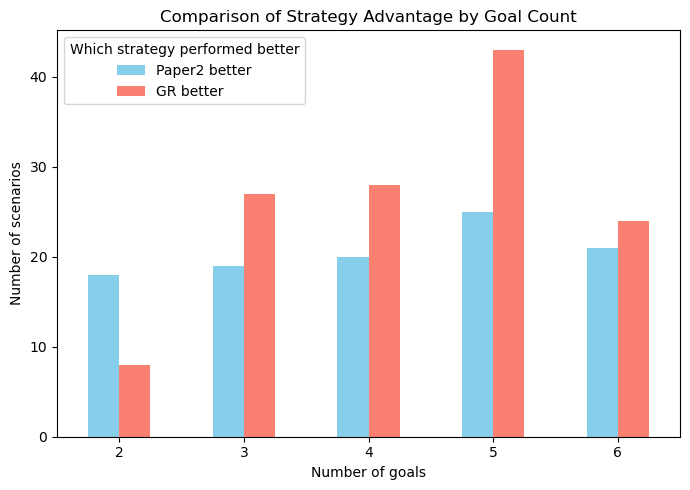

In [16]:
uniform_counts = uniform_better["num_goals"].value_counts().sort_index()
gr_counts = gr_better["num_goals"].value_counts().sort_index()

# 组合成一个 DataFrame 便于对比
compare_df = pd.DataFrame({
    "Paper2 better": uniform_counts,
    "GR better": gr_counts
}).fillna(0).astype(int)

print(compare_df)

# === 双柱对比图 ===
compare_df.plot(kind="bar", figsize=(7, 5), color=["skyblue", "salmon"])
plt.title("Comparison of Strategy Advantage by Goal Count")
plt.xlabel("Number of goals")
plt.ylabel("Number of scenarios")
plt.xticks(rotation=0)
plt.legend(title="Which strategy performed better")
plt.tight_layout()
plt.show()

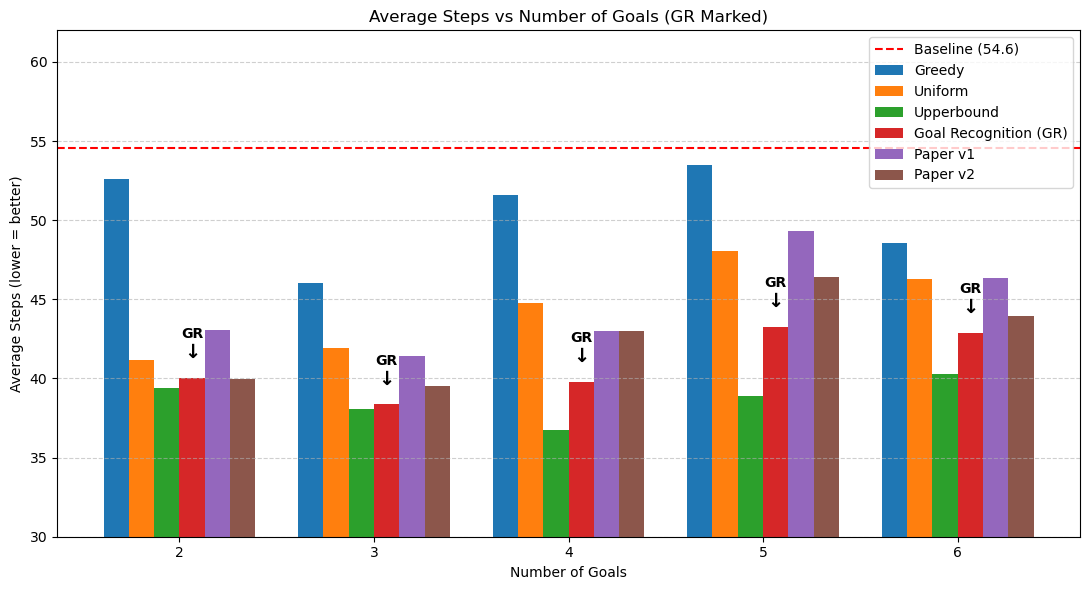

In [17]:
# 计算每个 num_goals 下的平均步数
avg_steps = df.groupby("num_goals")[[
    "steps_with_help_greedy",
    "steps_with_help_uniform",
    "steps_with_help_upperbound",
    "steps_with_help_gr",
    "steps_with_help_paper",
    "steps_with_help_paper2"
]].mean().reset_index()

# Baseline 平均
baseline_mean = df["steps_baseline"].mean()

# 绘图
plt.figure(figsize=(11, 6))
bar_width = 0.13
x = range(len(avg_steps))

# 原配色 + 原顺序
plt.bar([p - 2.5*bar_width for p in x], avg_steps["steps_with_help_greedy"], width=bar_width, label="Greedy")
plt.bar([p - 1.5*bar_width for p in x], avg_steps["steps_with_help_uniform"], width=bar_width, label="Uniform")
plt.bar([p - 0.5*bar_width for p in x], avg_steps["steps_with_help_upperbound"], width=bar_width, label="Upperbound")
bars_gr = plt.bar([p + 0.5*bar_width for p in x], avg_steps["steps_with_help_gr"], width=bar_width, label="Goal Recognition (GR)")
plt.bar([p + 1.5*bar_width for p in x], avg_steps["steps_with_help_paper"], width=bar_width, label="Paper v1")
plt.bar([p + 2.5*bar_width for p in x], avg_steps["steps_with_help_paper2"], width=bar_width, label="Paper v2")

# baseline 水平线
plt.axhline(y=baseline_mean, color='red', linestyle='--', linewidth=1.5, label=f"Baseline ({baseline_mean:.1f})")

# 🔹 在 GR 柱上方添加箭头和文字
for bar in bars_gr:
    height = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    # 箭头符号
    plt.text(x_pos, height + 1, "↓", ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
    # 标注文字
    plt.text(x_pos, height + 2.3, "GR", ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

# 样式
plt.xlabel("Number of Goals")
plt.ylabel("Average Steps (lower = better)")
plt.title("Average Steps vs Number of Goals (GR Marked)")
plt.xticks(x, avg_steps["num_goals"])
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(30, 62)
plt.tight_layout()
plt.show()


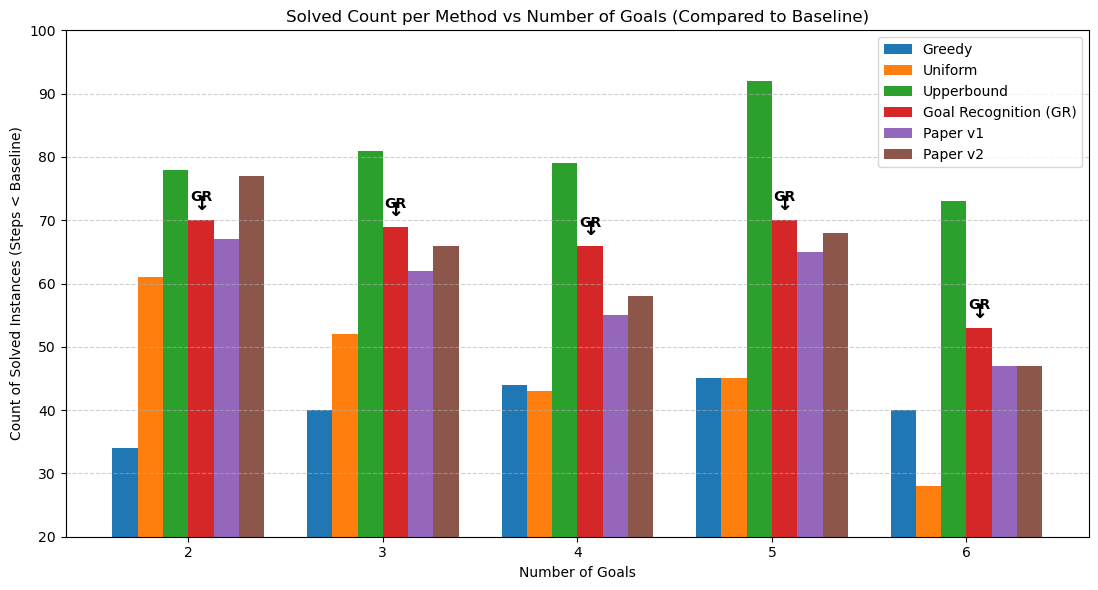

In [18]:
# 方法列表（包含 upperbound）
methods = [
    "steps_with_help_greedy",
    "steps_with_help_uniform",
    "steps_with_help_upperbound",
    "steps_with_help_gr",
    "steps_with_help_paper",
    "steps_with_help_paper2"
]

# 判断是否比 baseline 更好（步数更少 → 成功）
success_df = df.copy()
for col in methods:
    success_df[col] = success_df[col] < success_df["steps_baseline"]

# 按 goal 数量统计每个算法“成功”的次数
solved_counts = success_df.groupby("num_goals")[methods].sum().reset_index()

# 绘图
plt.figure(figsize=(11,6))
bar_width = 0.13
x = range(len(solved_counts))

# 顺序：Greedy – Uniform – Upperbound – GR – Paper v1 – Paper v2
plt.bar([p - 2.5*bar_width for p in x], solved_counts["steps_with_help_greedy"], width=bar_width, label="Greedy")
plt.bar([p - 1.5*bar_width for p in x], solved_counts["steps_with_help_uniform"], width=bar_width, label="Uniform")
plt.bar([p - 0.5*bar_width for p in x], solved_counts["steps_with_help_upperbound"], width=bar_width, label="Upperbound")
bars_gr = plt.bar([p + 0.5*bar_width for p in x], solved_counts["steps_with_help_gr"], width=bar_width, label="Goal Recognition (GR)")
plt.bar([p + 1.5*bar_width for p in x], solved_counts["steps_with_help_paper"], width=bar_width, label="Paper v1")
plt.bar([p + 2.5*bar_width for p in x], solved_counts["steps_with_help_paper2"], width=bar_width, label="Paper v2")

# 🔹 在 GR 柱子上方加箭头和文字标注
for bar in bars_gr:
    height = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    plt.text(x_pos, height + 1, "↓", ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
    plt.text(x_pos, height + 2.5, "GR", ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

# 样式
plt.xlabel("Number of Goals")
plt.ylabel("Count of Solved Instances (Steps < Baseline)")
plt.title("Solved Count per Method vs Number of Goals (Compared to Baseline)")
plt.xticks(x, solved_counts["num_goals"])
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.ylim(20, 100)
plt.show()

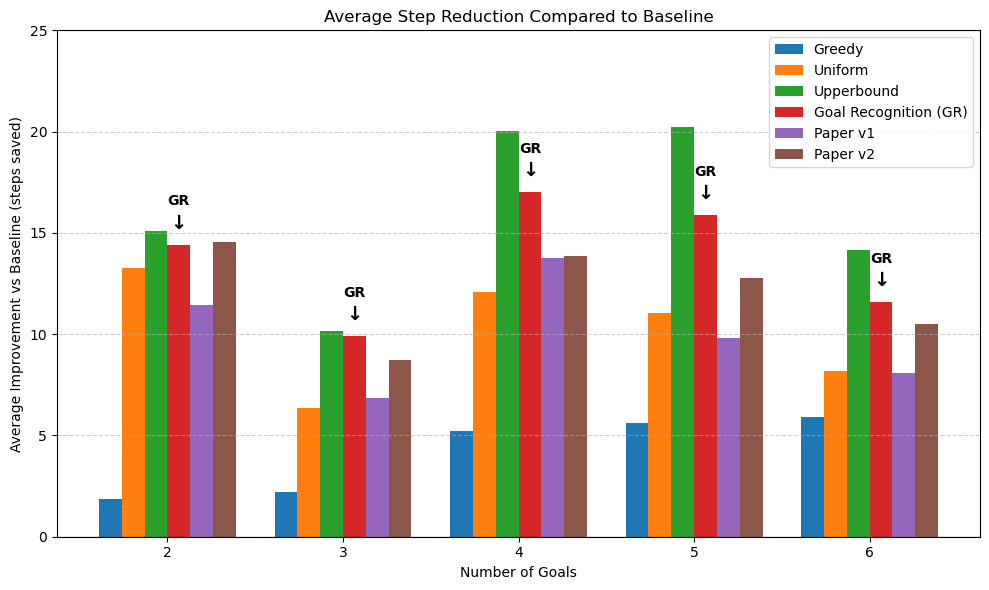

In [19]:
# 方法列表（加入 upperbound）
methods = [
    "steps_with_help_greedy",
    "steps_with_help_uniform",
    "steps_with_help_upperbound",
    "steps_with_help_gr",
    "steps_with_help_paper",
    "steps_with_help_paper2"
]

# 计算每个方法相对 baseline 的差值（baseline - 方法步数）
df_diff = df.copy()
for col in methods:
    df_diff[col] = df_diff["steps_baseline"] - df_diff[col]

# 对差值按 num_goals 求平均
avg_diff = df_diff.groupby("num_goals")[methods].mean().reset_index()

# 绘图
plt.figure(figsize=(10, 6))
bar_width = 0.13
x = range(len(avg_diff))

# 顺序：Greedy – Uniform – Upperbound – GR – Paper v1 – Paper v2
plt.bar([p - 2.5*bar_width for p in x], avg_diff["steps_with_help_greedy"], width=bar_width, label="Greedy")
plt.bar([p - 1.5*bar_width for p in x], avg_diff["steps_with_help_uniform"], width=bar_width, label="Uniform")
plt.bar([p - 0.5*bar_width for p in x], avg_diff["steps_with_help_upperbound"], width=bar_width, label="Upperbound")
bars_gr = plt.bar([p + 0.5*bar_width for p in x], avg_diff["steps_with_help_gr"], width=bar_width, label="Goal Recognition (GR)")
plt.bar([p + 1.5*bar_width for p in x], avg_diff["steps_with_help_paper"], width=bar_width, label="Paper v1")
plt.bar([p + 2.5*bar_width for p in x], avg_diff["steps_with_help_paper2"], width=bar_width, label="Paper v2")

# baseline 参考线
plt.axhline(0, color="black", linewidth=0.8)

# 🔹 给 GR 柱子加箭头和标注
for bar in bars_gr:
    height = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    plt.text(x_pos, height + 0.6, "↓", ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
    plt.text(x_pos, height + 1.8, "GR", ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

# 样式
plt.xlabel("Number of Goals")
plt.ylabel("Average Improvement vs Baseline (steps saved)")
plt.title("Average Step Reduction Compared to Baseline")
plt.xticks(x, avg_diff["num_goals"])
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, 25)
plt.tight_layout()
plt.show()

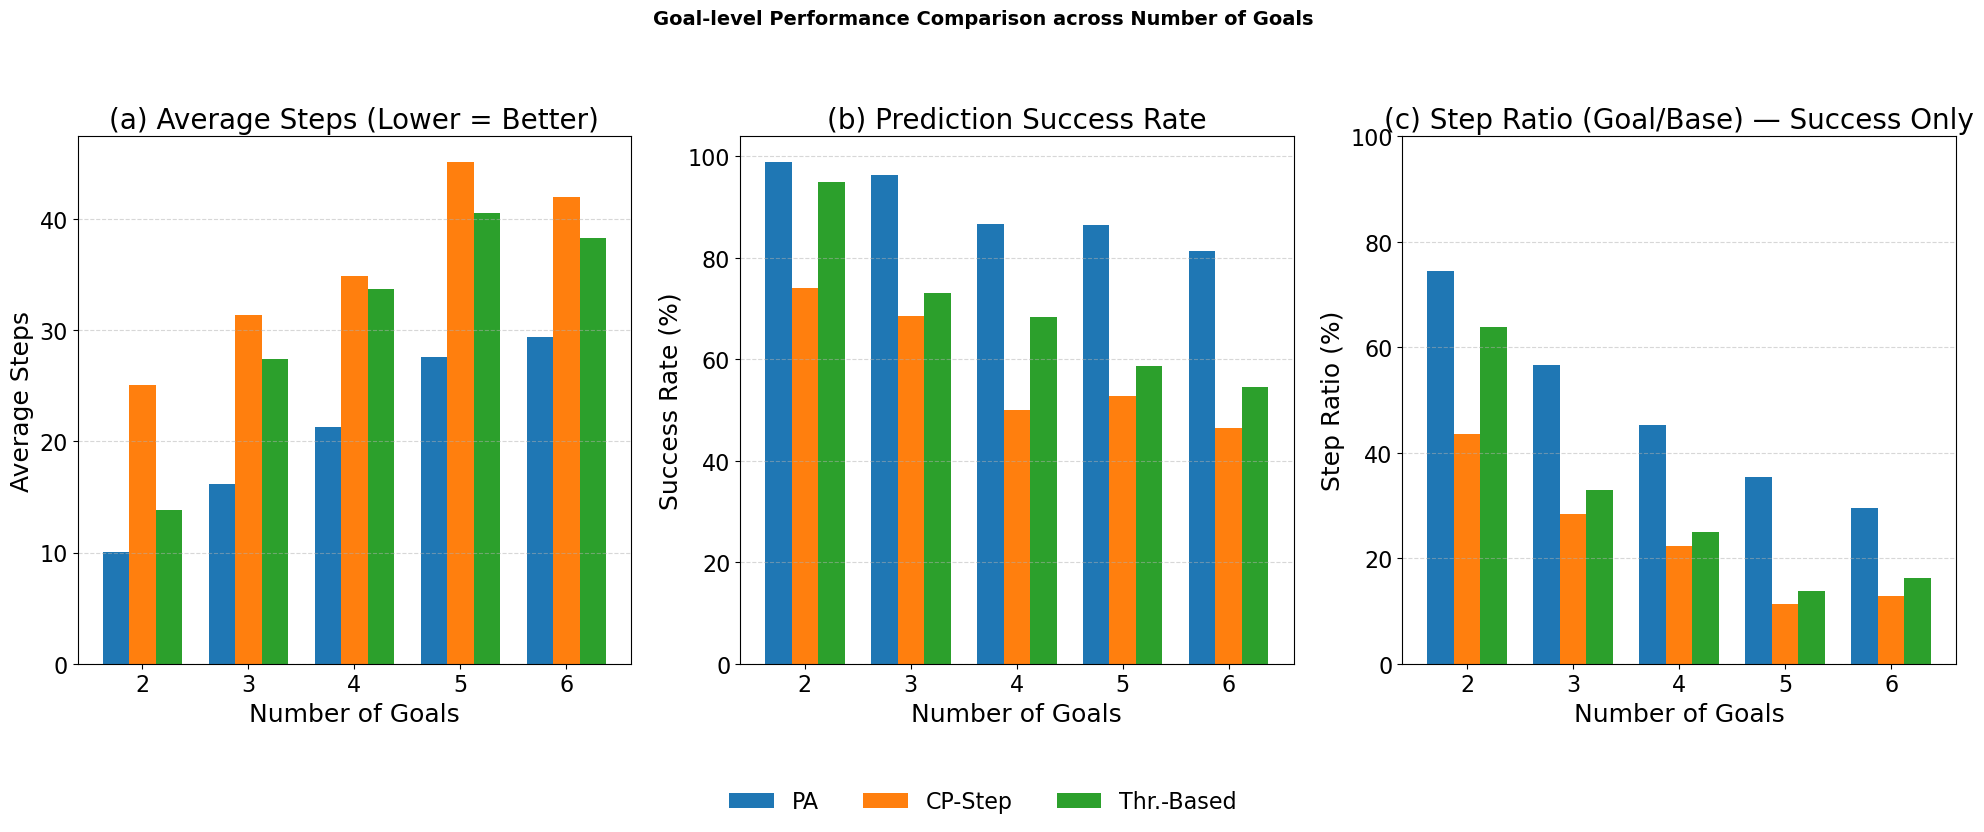

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========== 数据准备 ==========
cols_base = {
    "gr_goal":   ("steps_with_help_gr_goal",   "steps_with_help_gr"),
    "paper_goal":("steps_with_help_paper_goal","steps_with_help_paper"),
    "paper2_goal":("steps_with_help_paper2_goal","steps_with_help_paper2"),
}
need_cols = [c for pair in cols_base.values() for c in pair]
dfc = df[need_cols + ["num_goals"]].copy()
bar_width = 0.25

# ---------- (1) 平均步数 ----------
avg_steps = (
    dfc.groupby("num_goals")[[v[0] for v in cols_base.values()]]
    .mean().reset_index()
)
x = np.arange(len(avg_steps))

# ---------- (2) 预测成功率 ----------
success_rate = (
    dfc.assign(
        gr_succ=lambda d: (d["steps_with_help_gr_goal"] != d["steps_with_help_gr"]).astype(int),
        paper_succ=lambda d: (d["steps_with_help_paper_goal"] != d["steps_with_help_paper"]).astype(int),
        paper2_succ=lambda d: (d["steps_with_help_paper2_goal"] != d["steps_with_help_paper2"]).astype(int),
    )
    .groupby("num_goals")[["gr_succ", "paper_succ", "paper2_succ"]]
    .mean()
    .reset_index()
)

# ---------- (3) 成功样本下比例 ----------
for name, (goal_col, base_col) in cols_base.items():
    mask_success = dfc[base_col] != -1
    dfc[name + "_ratio"] = 1-(dfc.loc[mask_success, goal_col] / dfc.loc[mask_success, base_col])

ratio_df = (
    dfc.groupby("num_goals")[
        ["gr_goal_ratio", "paper_goal_ratio", "paper2_goal_ratio"]
    ]
    .mean()
    .reset_index()
)

print()

# ========== 综合绘图 ==========
plt.rcParams.update({
    'font.size': 18,          # 默认字体大小
    'axes.titlesize': 20,     # 子图标题
    'axes.labelsize': 18,     # 坐标轴标题
    'xtick.labelsize': 16,    # X轴刻度
    'ytick.labelsize': 16,    # Y轴刻度
    'legend.fontsize': 16,    # 图例
    'figure.titlesize': 22    # 整体标题
})

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True)
bar_width = 0.25
x = np.arange(len(avg_steps))

# --- (a) 平均步数 ---
axes[0].bar(x - bar_width, avg_steps["steps_with_help_gr_goal"], width=bar_width, label="PA")
axes[0].bar(x, avg_steps["steps_with_help_paper_goal"], width=bar_width, label="CP-Step")
axes[0].bar(x + bar_width, avg_steps["steps_with_help_paper2_goal"], width=bar_width, label="Thr.-Based")
axes[0].set_title("(a) Average Steps (Lower = Better)")
axes[0].set_xlabel("Number of Goals")
axes[0].set_ylabel("Average Steps")
axes[0].set_xticks(x)
axes[0].set_xticklabels(avg_steps["num_goals"])
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# --- (b) 成功率 ---
axes[1].bar(x - bar_width, success_rate["gr_succ"]*100, width=bar_width, label="PA")
axes[1].bar(x, success_rate["paper_succ"]*100, width=bar_width, label="CP-Step")
axes[1].bar(x + bar_width, success_rate["paper2_succ"]*100, width=bar_width, label="Thr.-Based")
axes[1].set_title("(b) Prediction Success Rate")
axes[1].set_xlabel("Number of Goals")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(success_rate["num_goals"])
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# --- (c) 成功样本下比例 ---
axes[2].bar(x - bar_width, ratio_df["gr_goal_ratio"]*100, width=bar_width, label="PA (Success Cases)")
axes[2].bar(x, ratio_df["paper_goal_ratio"]*100, width=bar_width, label="CP-Step (Success Cases)")
axes[2].bar(x + bar_width, ratio_df["paper2_goal_ratio"]*100, width=bar_width, label="Thr.-Based (Success Cases)")
axes[2].set_title("(c) Step Ratio (Goal/Base) — Success Only")
axes[2].set_xlabel("Number of Goals")
axes[2].set_ylabel("Step Ratio (%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(ratio_df["num_goals"])
axes[2].grid(axis="y", linestyle="--", alpha=0.5)
axes[2].set_ylim(0, 100)

# --- 全局标题与唯一图例 ---
fig.suptitle("Goal-level Performance Comparison across Number of Goals",
             fontsize=14, fontweight='bold')

# ✅ 图例只出现一次（放底部中间）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center",
           bbox_to_anchor=(0.5, -0.05),
           ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

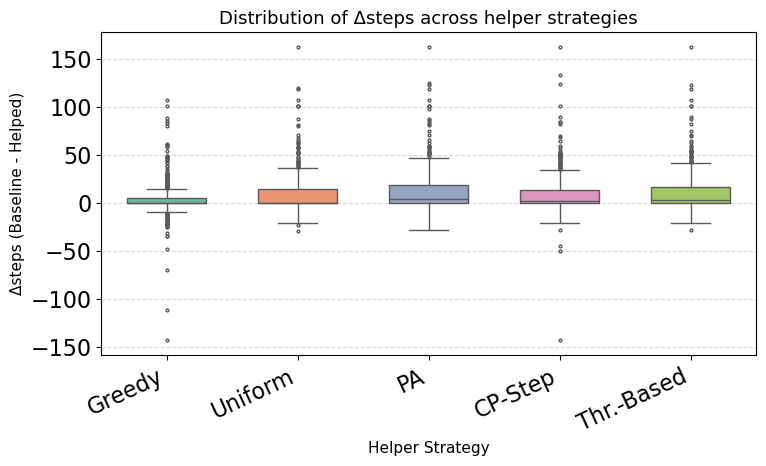

In [21]:
# 假设 df_all 已经加载并清洗
base_col = "steps_baseline"
help_cols = [
    ("steps_with_help_greedy",  "Greedy"),
    ("steps_with_help_uniform", "Uniform"),
    ("steps_with_help_gr",      "PA"),
    #("steps_with_help_upperbound", "Upperbound"),
    ("steps_with_help_paper",   "CP-Step"),
    ("steps_with_help_paper2",  "Thr.-Based")
]

# 汇总所有策略的 Δsteps 到一个长表
records = []
for col, label in help_cols:
    if col not in df_all.columns:
        continue
    diff = df_all[base_col] - df_all[col]
    for val in diff.dropna():
        records.append({"Method": label, "Δsteps": val})

df_plot = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_plot,
    x="Method", y="Δsteps",
    hue="Method",       # ✅ 告诉 seaborn 用 Method 来上色
    palette="Set2",
    legend=False,       # ✅ 不显示重复图例
    width=0.6,
    fliersize=2
)

plt.title("Distribution of Δsteps across helper strategies", fontsize=13)
plt.ylabel("Δsteps (Baseline - Helped)", fontsize=11)
plt.xlabel("Helper Strategy", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

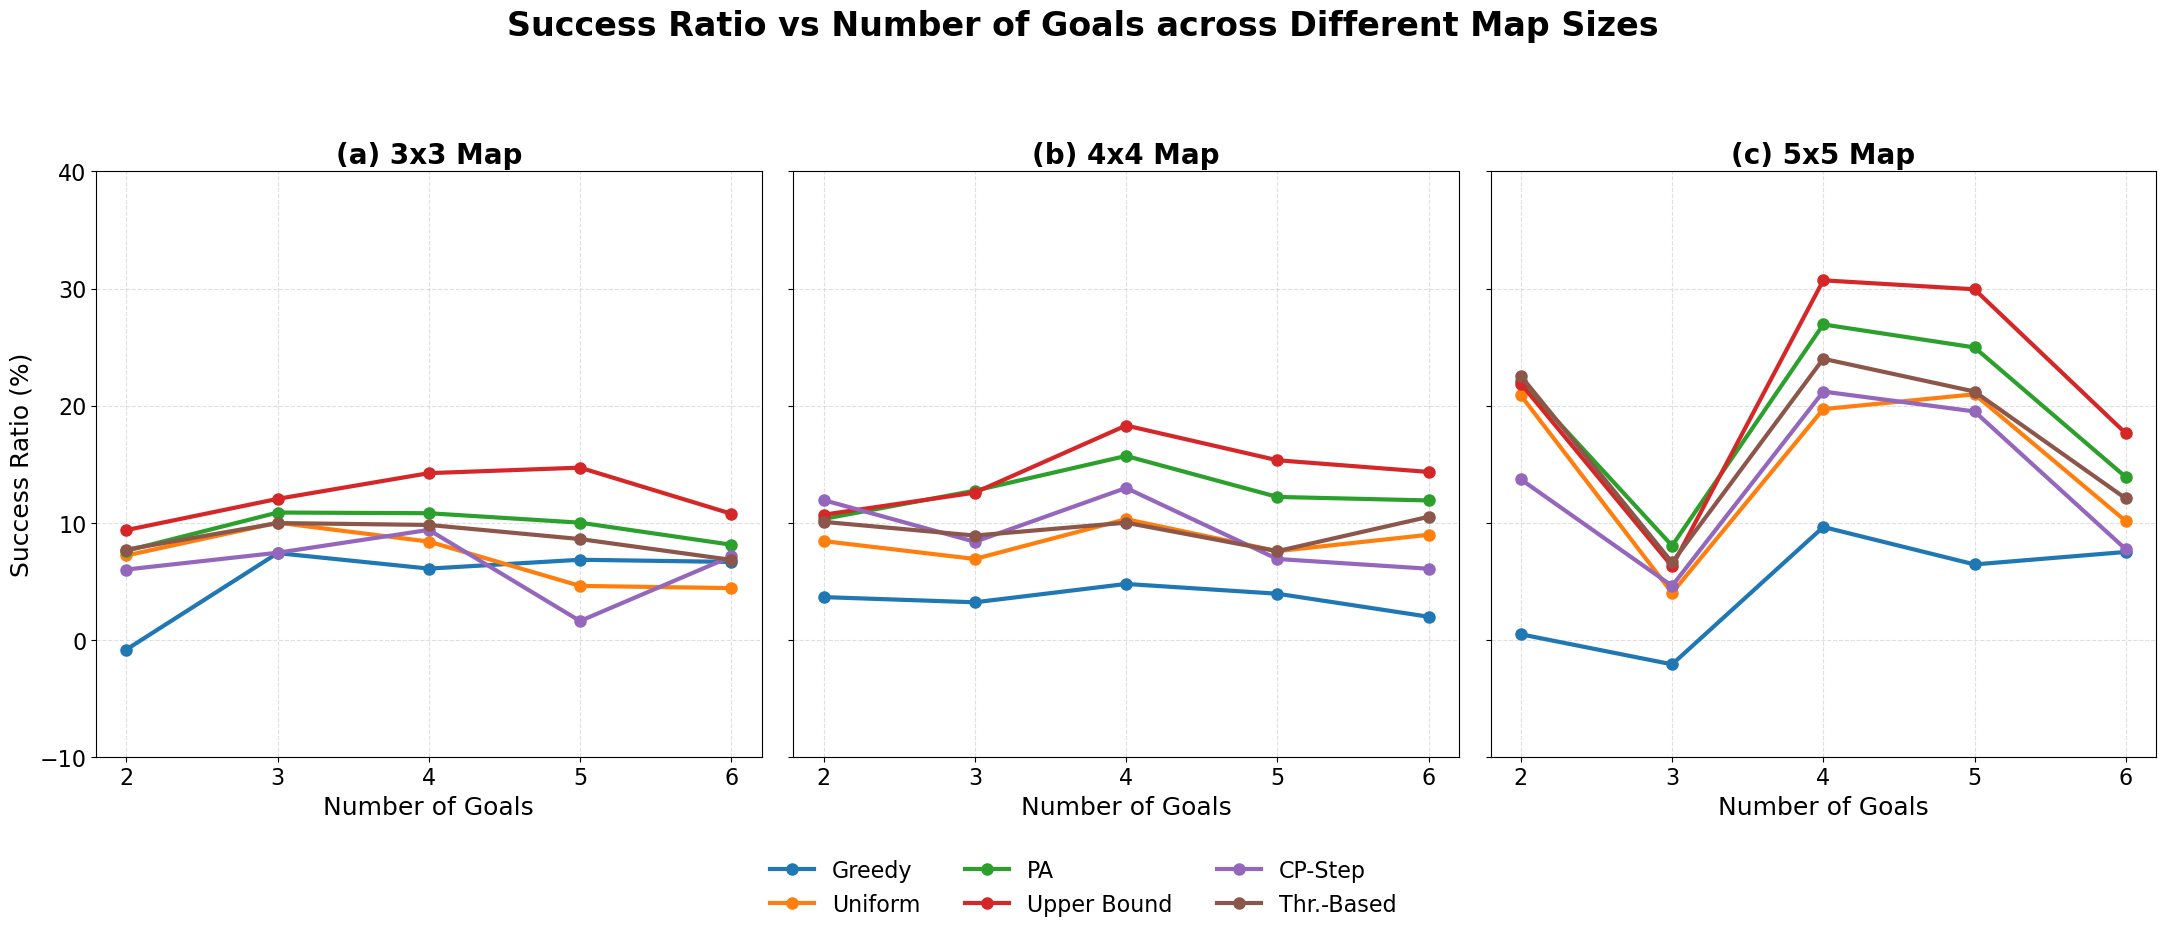

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# 1) 准备：生成 map_size 字段
# =========================================================
df = df.copy()
df["map_size"] = df["num_rows"].astype(str) + "x" + df["num_cols"].astype(str)

# 你的算法列映射
algo_cols = {
    "Greedy": "steps_with_help_greedy",
    "Uniform": "steps_with_help_uniform",
    "PA": "steps_with_help_gr",
    "Upper Bound": "steps_with_help_upperbound",
    "CP-Step": "steps_with_help_paper",
    "Thr.-Based": "steps_with_help_paper2",
}
base_col = "steps_baseline"

# =========================================================
# 2) 计算 df_success：每个 (map_size, num_goals) 下，各算法成功率（%）
#    规则：success = (help_steps < baseline_steps)
# =========================================================

rows = []
for (ms, ng), g in df.groupby(["map_size", "num_goals"]):
    
    # 每组随机抽样 100 个（不足 100 则全部）
    g_sample = g.sample(n=min(30, len(g)), replace=False, random_state=42)
    
    row = {"map_size": ms, "num_goals": ng}
    
    for name, col in algo_cols.items():
        diff = (g_sample[base_col] - g_sample[col]).astype(float)
        row[name] = diff.mean()   # 平均减少步数
        
    rows.append(row)
    
# rows = []
# for (ms, ng), g in df.groupby(["map_size", "num_goals"]):
#     row = {"map_size": ms, "num_goals": ng}
#     for name, col in algo_cols.items():
#         # m = (g[col] < g[base_col]).astype(float)
#         # row[name] = m.mean() * 100.0   # 成功率（%）
#         diff = (g[base_col] - g[col]).astype(float)
#         row[name] = diff.mean()

#     rows.append(row)

df_success = pd.DataFrame(rows).sort_values(["map_size", "num_goals"]).reset_index(drop=True)

# =========================================================
# 3) 画图（放大字体版）
# =========================================================
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})

fig, axes = plt.subplots(1, 3, figsize=(22, 9), sharey=True)

map_list = ["3x3", "4x4", "5x5"]
for i, map_size in enumerate(map_list):
    subset = df_success[df_success["map_size"] == map_size].sort_values("num_goals")
    goals = subset["num_goals"].tolist()
    ax = axes[i]
    for name in algo_cols.keys():
        ax.plot(goals, subset[name], marker='o', markersize=8, linewidth=3, label=name)
    ax.set_title(f"({chr(97+i)}) {map_size} Map", fontweight='bold')
    ax.set_xlabel("Number of Goals")
    ax.set_xticks(goals)
    ax.grid(alpha=0.4, linestyle="--")
    if i == 0:
        ax.set_ylabel("Success Ratio (%)")
    ax.set_ylim(-10, 40)

fig.suptitle("Success Ratio vs Number of Goals across Different Map Sizes",
             fontsize=24, fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()


In [23]:
import pandas as pd
import numpy as np

# ========== 数据准备 ==========
cols_base = {
    "gr_goal":   ("steps_with_help_gr_goal",   "steps_with_help_gr"),
    "paper_goal":("steps_with_help_paper_goal","steps_with_help_paper"),
    "paper2_goal":("steps_with_help_paper2_goal","steps_with_help_paper2"),
}

need_cols = [c for pair in cols_base.values() for c in pair]
dfc = df[need_cols + ["num_goals"]].copy()

# ---------- (1) 平均步数（排除 -1） ----------
for name, (goal_col, _) in cols_base.items():
    dfc[goal_col] = pd.to_numeric(dfc[goal_col], errors="coerce")
avg_steps = (
    dfc[dfc[[v[0] for v in cols_base.values()]].ne(-1).all(axis=1)]  # 去掉含 -1 的行
    .groupby("num_goals")[[v[0] for v in cols_base.values()]]
    .mean()
    .reset_index()
)

# ---------- (2) 预测成功率 ----------
# 成功 = goal 列 != -1
success_rate = (
    dfc.assign(
        gr_succ=lambda d: (d["steps_with_help_gr_goal"] != -1).astype(int),
        paper_succ=lambda d: (d["steps_with_help_paper_goal"] != -1).astype(int),
        paper2_succ=lambda d: (d["steps_with_help_paper2_goal"] != -1).astype(int),
    )
    .groupby("num_goals")[["gr_succ", "paper_succ", "paper2_succ"]]
    .mean()
    .reset_index()
)

# ---------- (3) 成功样本下比例 ----------
for name, (goal_col, base_col) in cols_base.items():
    mask_success = dfc[goal_col] != -1
    dfc[name + "_ratio"] = 1 - (dfc.loc[mask_success, goal_col] / dfc.loc[mask_success, base_col])
    

ratio_df = (
    dfc.groupby("num_goals")[
        ["gr_goal_ratio", "paper_goal_ratio", "paper2_goal_ratio"]
    ]
    .mean()
    .reset_index()
)

# ========== 打印结果 ==========
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
pd.set_option("display.precision", 3)

print("\n========== (1) 平均步数 avg_steps (已排除 -1) ==========")
print(avg_steps.round(3))

print("\n========== (2) 预测成功率 success_rate (比例已转为百分比) ==========")
print((success_rate * 100).round(2))

print("\n========== (3) 成功样本下比例 ratio_df (goal/base × 100%) ==========")
print((ratio_df * 100).round(2))



========== (1) 平均步数 avg_steps (已排除 -1) ==========
   num_goals  steps_with_help_gr_goal  steps_with_help_paper_goal  steps_with_help_paper2_goal
0          2                   10.030                      25.050                       13.820
1          3                   16.157                      31.352                       27.435
2          4                   21.286                      34.867                       33.714
3          5                   27.625                      45.154                       40.567
4          6                   29.402                      41.959                       38.278

========== (2) 预测成功率 success_rate (比例已转为百分比) ==========
   num_goals  gr_succ  paper_succ  paper2_succ
0        200    100.0       100.0        100.0
1        300    100.0       100.0        100.0
2        400    100.0       100.0        100.0
3        500    100.0       100.0        100.0
4        600    100.0       100.0        100.0

========== (3) 成功样本下比例 ratio_df (goal/b